# Project 3 — Multimodal BEV Perception

**Experiment ID:** P3-3C  
**Architecture:** Multimodal Fusion + Cross-Attention  
**Task:** BEV Occupancy Prediction  
**Dataset:** nuScenes-mini


**Objective**

Evaluate whether symmetric cross-modal attention
between RGB and LiDAR feature representations
improves multimodal BEV occupancy prediction.

---

**Inputs**

- RGB image
- LiDAR BEV occupancy
- IMU sequence

**Output**

- Binary BEV occupancy map

**Architecture**

Fusion + Cross Attention

---

This notebook implements the complete training,
evaluation, visualization, and error analysis
pipeline for the Cross Attention fusion model.

## Experiment Metadata

| Item | Value |
|------|-------|
| Model | Fusion + Cross Attention |
| Inputs | RGB + LiDAR + IMU |
| Output | Binary BEV Occupancy |
| Loss | Hybrid BCE + Dice |
| Optimizer | Adam |
| Epochs | 40 |
| Hardware | GPU |

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
checkpoints	data	    notebooks  README.md  scripts
colab_packages	dummy.onnx  nuscenes   reports	  src


In [ ]:
import os, sys
# --- System ---
sys.path.append('/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/colab_packages')


In [ ]:
import sys, os, importlib
# Make sure your src/ directory is visible to Python
project_root = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception"
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f" Added to sys.path: {src_path}")

# Clear any stale caches
importlib.invalidate_caches()

## 1. Environment Setup

In [ ]:
# ============================================================
# Project 3 — Phase 3c
# Fusion + Cross Attention
#
# Environment Setup
#
# This cell imports all required libraries, initializes the
# computation device, and configures PyTorch runtime settings.
# ============================================================

import os
import time

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from src.dataset_utils import RGBBEVDataset
from src.losses import HybridLoss
from src.model.fusion_xattn import FusionCrossAttentionModel
from src.report_utils import save_report


# ---------------------------------------------------
# Device configuration
# ---------------------------------------------------
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Using device: {device}")

if torch.cuda.is_available():

    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )


# ---------------------------------------------------
# Runtime configuration
#
# Enable cuDNN benchmarking to select the fastest
# convolution algorithms for fixed input sizes.
# ---------------------------------------------------
torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# ============================================================
# Dataset Preparation
#
# Load the preprocessed multimodal dataset, perform an
# 80/20 train-validation split, and construct PyTorch
# DataLoaders for training and evaluation.
# ============================================================

# ---------------------------------------------------
# Dataset location
# ---------------------------------------------------
data_dir = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "project3_multimodal_bev_perception/"
    "data/preprocessed_moving"
)

# ---------------------------------------------------
# Discover all HDF5 samples
# ---------------------------------------------------
files = sorted(
    [
        os.path.join(data_dir, filename)
        for filename in os.listdir(data_dir)
        if filename.endswith(".h5")
    ]
)

print(
    f"Found {len(files)} HDF5 files in:\n{data_dir}"
)

# ---------------------------------------------------
# Train / Validation split (80 / 20)
# ---------------------------------------------------
split_idx = int(
    0.8 * len(files)
)

train_files = files[:split_idx]
val_files = files[split_idx:]

# ---------------------------------------------------
# Dataset objects
# ---------------------------------------------------
train_set = RGBBEVDataset(
    train_files,
)

val_set = RGBBEVDataset(
    val_files,
)

# ---------------------------------------------------
# DataLoaders
# ---------------------------------------------------
BATCH_SIZE = 8

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# ---------------------------------------------------
# Verify one training sample
# ---------------------------------------------------
rgb, bev, imu = train_set[0]

print("\nSample tensor shapes")
print("--------------------")
print(f"RGB Input : {tuple(rgb.shape)}")
print(f"LiDAR BEV : {tuple(bev.shape)}")
print(f"IMU       : {tuple(imu.shape)}")

print("\nDataset summary")
print("----------------")
print(f"Training samples   : {len(train_set)}")
print(f"Validation samples : {len(val_set)}")
print(f"Batch size         : {BATCH_SIZE}")

Found 323 HDF5 files in:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed_moving

Sample tensor shapes
--------------------
RGB Input : (3, 256, 256)
LiDAR BEV : (1, 200, 200)
IMU       : (10, 6)

Dataset summary
----------------
Training samples   : 258
Validation samples : 65
Batch size         : 8


In [ ]:
# ============================================================
# Model Initialization
#
# Instantiate the Fusion + Cross Attention model,
# define the optimization objective, and configure
# the optimizer used for training.
# ============================================================

# ---------------------------------------------------
# Model
# ---------------------------------------------------
model = FusionCrossAttentionModel().to(
    device,
)

#print(model)

# ---------------------------------------------------
# Loss function
# ---------------------------------------------------
loss_fn = HybridLoss()

# ---------------------------------------------------
# Optimizer
# ---------------------------------------------------
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5,
)

# ---------------------------------------------------
# Model summary
# ---------------------------------------------------
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Fusion + Cross Attention")
print("-" * 30)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Fusion + Cross Attention
------------------------------
Total parameters     : 398,449
Trainable parameters : 398,449


## 4. Training

Train the Cross Attention model for 40 epochs.

The best-performing checkpoint is selected
according to validation IoU.

In [ ]:
from tqdm import tqdm

import os
import time


def soft_iou(
    pred,
    target,
    smooth=1e-6,
):
    """
    Compute the mean binary Intersection-over-Union (IoU)
    between predicted and ground-truth BEV occupancy maps.
    """

    pred_bin = (pred > 0.5).float()

    intersection = (
        pred_bin * target
    ).sum(dim=(2, 3))

    union = (
        pred_bin.sum(dim=(2, 3))
        + target.sum(dim=(2, 3))
        - intersection
    )

    return (
        (intersection + smooth)
        / (union + smooth)
    ).mean().item()


# ---------------------------------------------------
# Training configuration
# ---------------------------------------------------
EPOCHS = 40

best_val_iou = 0.0

t0 = time.time()


# ---------------------------------------------------
# Training loop
# ---------------------------------------------------
for epoch in range(EPOCHS):

    model.train()

    train_loss = 0.0

    for rgb, bev, imu in tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        ncols=90,
    ):

        rgb = rgb.to(device)
        bev = bev.to(device)
        imu = imu.to(device)

        logits = model(
            rgb,
            bev,
            imu,
        )

        # ---------------------------------------------------
        # Resize the ground-truth BEV map if the prediction
        # resolution differs from the model output.
        # ---------------------------------------------------
        if bev.shape[-2:] != logits.shape[-2:]:

            bev = F.interpolate(
                bev,
                size=logits.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        loss = loss_fn(
            logits,
            bev,
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------------------------------------------------
    # Validation
    # ---------------------------------------------------
    model.eval()

    val_loss = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for rgb, bev, imu in val_loader:

            rgb = rgb.to(device)
            bev = bev.to(device)
            imu = imu.to(device)

            logits = model(
                rgb,
                bev,
                imu,
            )

            if bev.shape[-2:] != logits.shape[-2:]:

                bev = F.interpolate(
                    bev,
                    size=logits.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )

            val_loss += loss_fn(
                logits,
                bev,
            ).item()

            val_iou += soft_iou(
                logits,
                bev,
            )

    val_loss /= len(val_loader)

    val_iou /= len(val_loader)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f}"
    )

    # ---------------------------------------------------
    # Save the checkpoint with the highest validation IoU.
    # ---------------------------------------------------
    if val_iou > best_val_iou:

        best_val_iou = val_iou

        os.makedirs(
            "checkpoints",
            exist_ok=True,
        )

        torch.save(
            model.state_dict(),
            "checkpoints/fusion_xattn_best.pth",
        )


# ---------------------------------------------------
# Training summary
# ---------------------------------------------------
t1 = time.time()

print(
    "\nTraining complete."
)

print(
    f"Best Validation IoU : {best_val_iou:.4f}"
)

print(
    f"Training time       : {(t1 - t0) / 60:.2f} minutes"
)

Epoch 1/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 12.53it/s]


Epoch 01/40 | Train Loss: 0.7089 | Val Loss: 0.6654 | Val IoU: 0.2754


Epoch 2/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 15.06it/s]


Epoch 02/40 | Train Loss: 0.6700 | Val Loss: 0.6550 | Val IoU: 0.2646


Epoch 3/40: 100%|█████████████████████████████████████████| 33/33 [00:02<00:00, 14.73it/s]


...

Epoch 38/40 | Train Loss: 0.5023 | Val Loss: 0.5038 | Val IoU: 0.2617


Epoch 39/40: 100%|████████████████████████████████████████| 33/33 [00:02<00:00, 14.43it/s]


Epoch 39/40 | Train Loss: 0.4989 | Val Loss: 0.5017 | Val IoU: 0.2687


Epoch 40/40: 100%|████████████████████████████████████████| 33/33 [00:02<00:00, 13.94it/s]


Epoch 40/40 | Train Loss: 0.4956 | Val Loss: 0.4989 | Val IoU: 0.2768

Training complete.
Best Validation IoU : 0.2909
Training time       : 1.81 minutes


In [ ]:
# ============================================================
# Quantitative Evaluation
#
# Evaluate the best-performing Fusion + Cross Attention model
# on the validation dataset using standard binary occupancy
# segmentation metrics.
#
# Metrics
#   • Mean IoU
#   • Mean Precision
#   • Mean Recall
#   • Mean F1 Score
# ============================================================


def compute_metrics(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute binary segmentation metrics for a single
    BEV occupancy prediction.

    Parameters
    ----------
    pred : ndarray
        Predicted probability map.

    target : ndarray
        Ground-truth occupancy map.

    thresh : float, default=0.5
        Threshold used to obtain a binary prediction.

    Returns
    -------
    tuple
        (IoU, Precision, Recall, F1 Score)
    """

    pred_bin = (
        pred > thresh
    ).astype(np.uint8)

    target_bin = (
        target > 0.5
    ).astype(np.uint8)

    tp = np.logical_and(
        pred_bin == 1,
        target_bin == 1,
    ).sum()

    fp = np.logical_and(
        pred_bin == 1,
        target_bin == 0,
    ).sum()

    fn = np.logical_and(
        pred_bin == 0,
        target_bin == 1,
    ).sum()

    precision = tp / (tp + fp + 1e-6)

    recall = tp / (tp + fn + 1e-6)

    f1 = (
        2 * precision * recall
        / (precision + recall + 1e-6)
    )

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    iou = intersection / (union + 1e-6)

    return (
        iou,
        precision,
        recall,
        f1,
    )


# ---------------------------------------------------
# Load best checkpoint
# ---------------------------------------------------
model.load_state_dict(
    torch.load(
        "checkpoints/fusion_xattn_best.pth",
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Evaluate validation set
# ---------------------------------------------------
iou_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

with torch.no_grad():

    for rgb, bev, imu in val_loader:

        rgb = rgb.to(device)
        bev = bev.to(device)
        imu = imu.to(device)

        logits = model(
            rgb,
            bev,
            imu,
        )

        if logits.shape[-2:] != bev.shape[-2:]:

            logits = F.interpolate(
                logits,
                size=bev.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        probs = torch.sigmoid(
            logits
        )

        pred_np = probs.cpu().numpy()
        bev_np = bev.cpu().numpy()

        for pred, target in zip(
            pred_np,
            bev_np,
        ):

            iou, precision, recall, f1 = compute_metrics(
                pred[0],
                target[0],
            )

            iou_scores.append(iou)
            precision_scores.append(precision)
            recall_scores.append(recall)
            f1_scores.append(f1)


# ---------------------------------------------------
# Aggregate results
# ---------------------------------------------------
summary_dict = {
    "Mean IoU": np.mean(iou_scores),
    "Mean Precision": np.mean(precision_scores),
    "Mean Recall": np.mean(recall_scores),
    "Mean F1": np.mean(f1_scores),
}


print("\nValidation Performance")
print("----------------------")

for metric, value in summary_dict.items():

    print(
        f"{metric:<17}: {value:.4f}"
    )


# ---------------------------------------------------
# Save experiment report
# ---------------------------------------------------
save_report(
    summary_dict,
    model_name="FusionCrossAttentionModel (RGB + LiDAR + IMU)",
    best_iou=summary_dict["Mean IoU"],
    start_time=t0,
    end_time=t1,
    auto_update=True,
)


Validation Performance
----------------------
Mean IoU         : 0.3000
Mean Precision   : 0.3796
Mean Recall      : 0.6111
Mean F1          : 0.4609
 Markdown report saved → reports/fusioncrossattentionmodel_rgb___lidar___imu_summary.md
 CSV report saved → reports/fusioncrossattentionmodel_rgb___lidar___imu_summary.csv
 Leaderboard saved → reports/leaderboard.csv
️ Markdown summary → reports/leaderboard.md
 Leaderboard plot saved → reports/leaderboard.png


('reports/fusioncrossattentionmodel_rgb___lidar___imu_summary.md',
 'reports/fusioncrossattentionmodel_rgb___lidar___imu_summary.csv')

Qualitative Evaluation

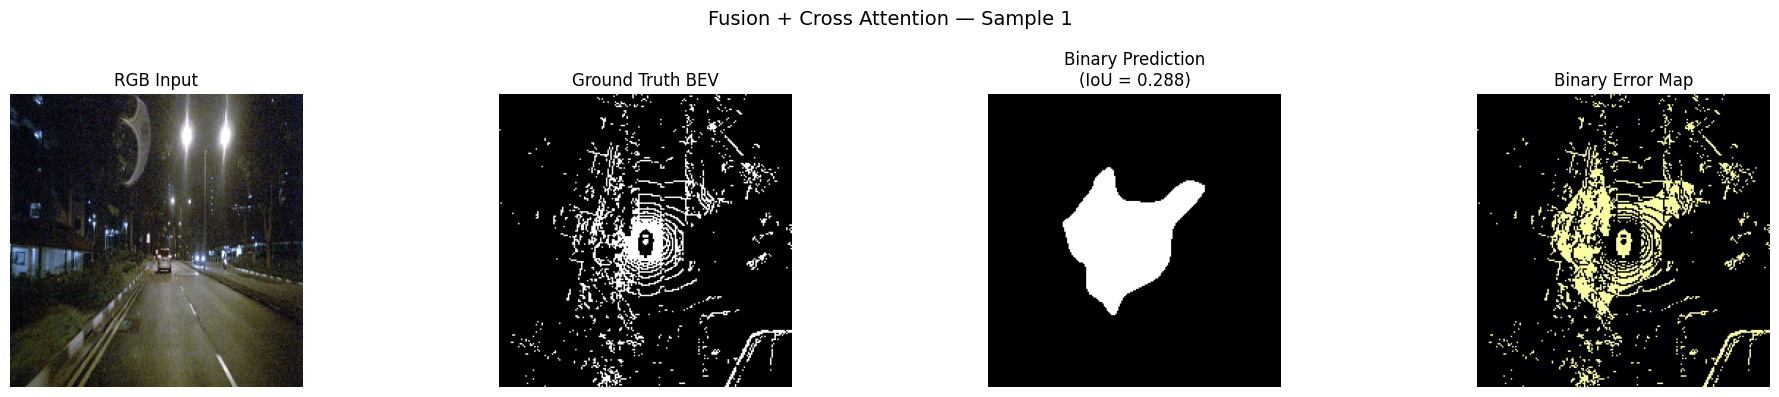

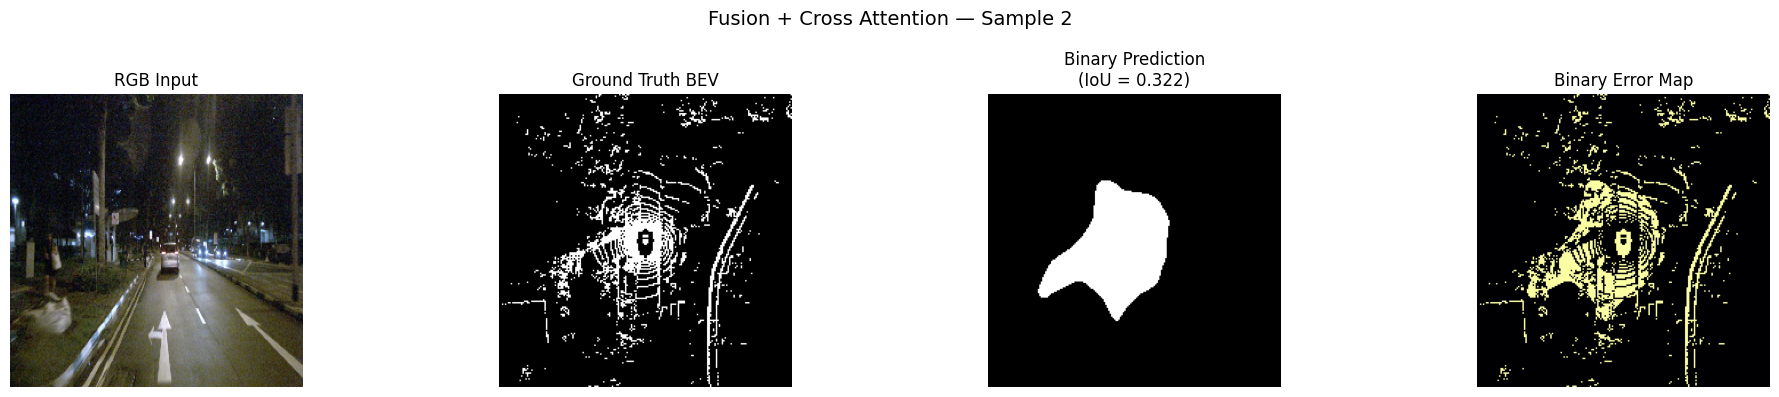

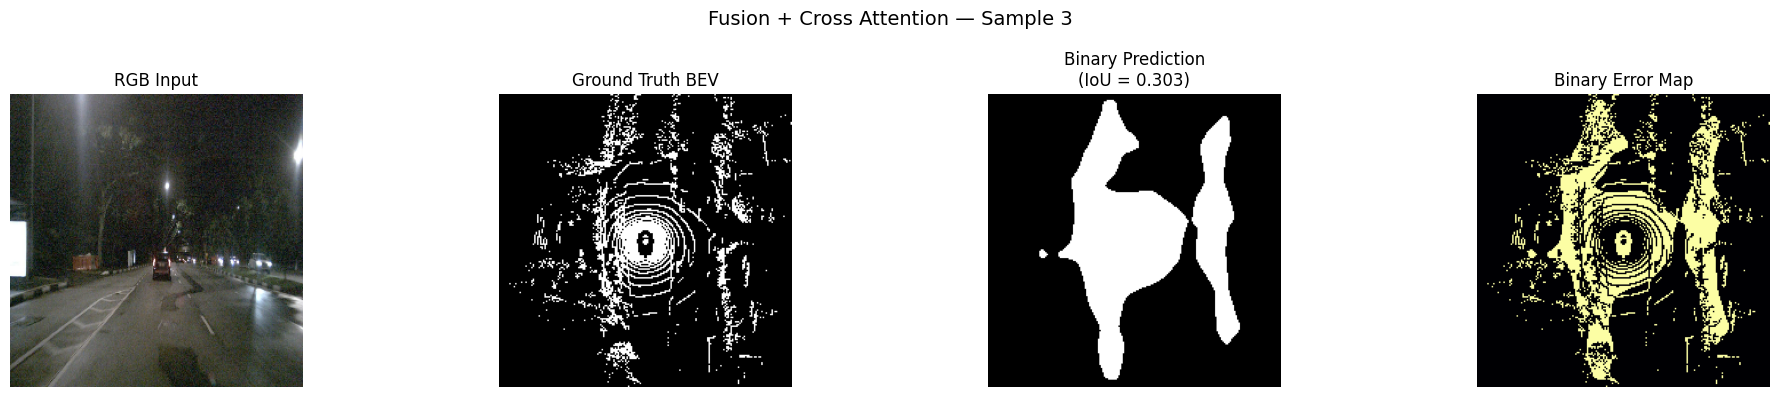

In [ ]:
# ============================================================
# Qualitative Evaluation
#
# Visualize representative validation samples to assess the
# qualitative performance of the Fusion + Cross Attention
# model.
#
# For each sample, the following are displayed:
#   • RGB input
#   • Ground-truth BEV occupancy map
#   • Predicted binary occupancy map
#   • Binary error map
# ============================================================

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


# ---------------------------------------------------
# Load best-performing checkpoint
# ---------------------------------------------------
checkpoint_path = "checkpoints/fusion_xattn_best.pth"

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Compute binary Intersection-over-Union
# ---------------------------------------------------
def compute_iou(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute the binary Intersection-over-Union (IoU)
    between a predicted BEV occupancy map and the
    corresponding ground-truth map.
    """

    pred_bin = (
        pred > thresh
    ).astype(np.uint8)

    target_bin = (
        target > 0.5
    ).astype(np.uint8)

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    return intersection / (union + 1e-6)


# ---------------------------------------------------
# Randomly sample validation examples
# ---------------------------------------------------
NUM_SAMPLES = 3

sample_indices = random.sample(
    range(len(val_set)),
    NUM_SAMPLES,
)


# ---------------------------------------------------
# Visualize predictions
# ---------------------------------------------------
for sample_num, idx in enumerate(sample_indices, start=1):

    rgb, bev, imu = val_set[idx]

    rgb_input = rgb.unsqueeze(0).to(device)
    bev_input = bev.unsqueeze(0).to(device)
    imu_input = imu.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = model(
            rgb_input,
            bev_input,
            imu_input,
        )

        probabilities = torch.sigmoid(
            logits
        )

        if probabilities.shape[-2:] != bev_input.shape[-2:]:

            probabilities = F.interpolate(
                probabilities,
                size=bev_input.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

    pred_np = probabilities.squeeze().cpu().numpy()

    gt_np = bev.squeeze().cpu().numpy()

    rgb_np = np.transpose(
        rgb.cpu().numpy(),
        (1, 2, 0),
    )

    # Recover display range
    rgb_np = (
        (rgb_np + 1.0) / 2.0
    ).clip(0, 1)

    pred_bin = (
        pred_np > 0.5
    ).astype(np.float32)

    iou = compute_iou(
        pred_np,
        gt_np,
    )

    error_map = np.abs(
        pred_bin - gt_np
    )

    # ---------------------------------------------------
    # Visualization
    # ---------------------------------------------------
    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 4),
    )

    axes[0].imshow(rgb_np)
    axes[0].set_title("RGB Input")
    axes[0].axis("off")

    axes[1].imshow(
        gt_np,
        cmap="gray",
    )
    axes[1].set_title("Ground Truth BEV")
    axes[1].axis("off")

    axes[2].imshow(
        pred_bin,
        cmap="gray",
    )
    axes[2].set_title(
        f"Binary Prediction\n(IoU = {iou:.3f})"
    )
    axes[2].axis("off")

    axes[3].imshow(
        error_map,
        cmap="inferno",
    )
    axes[3].set_title("Binary Error Map")
    axes[3].axis("off")

    plt.suptitle(
        f"Fusion + Cross Attention — Sample {sample_num}",
        fontsize=14,
    )

    plt.tight_layout()

    plt.show()

## 7. Error Analysis

Analyze representative validation examples
corresponding to:

- worst prediction
- median prediction
- best prediction

to better understand the strengths and
limitations of the proposed architecture.

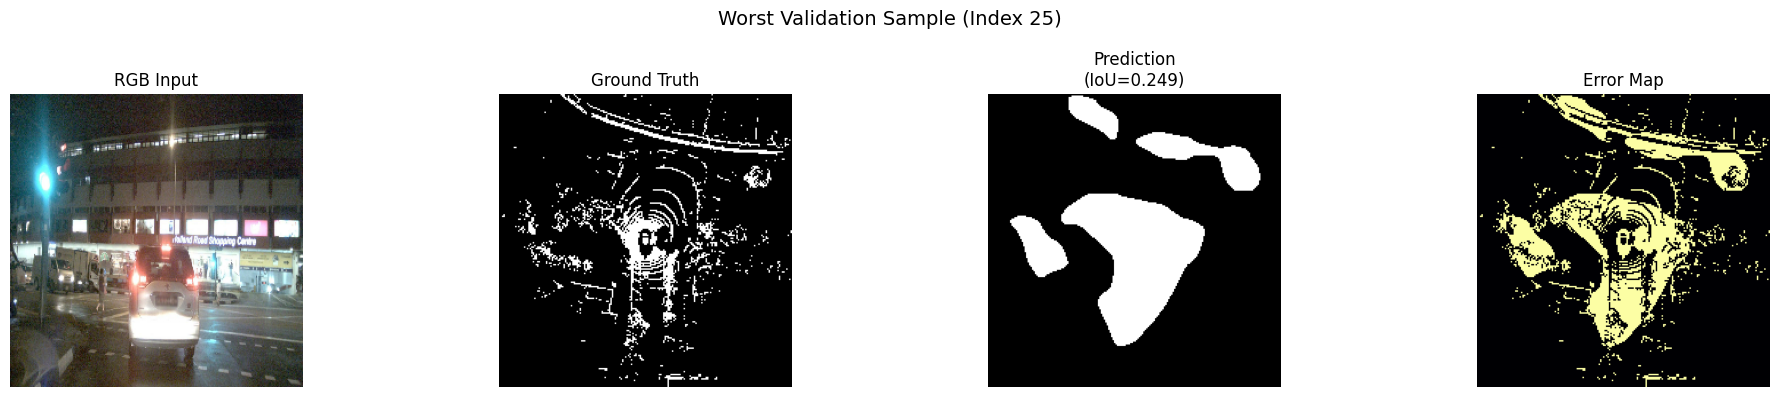

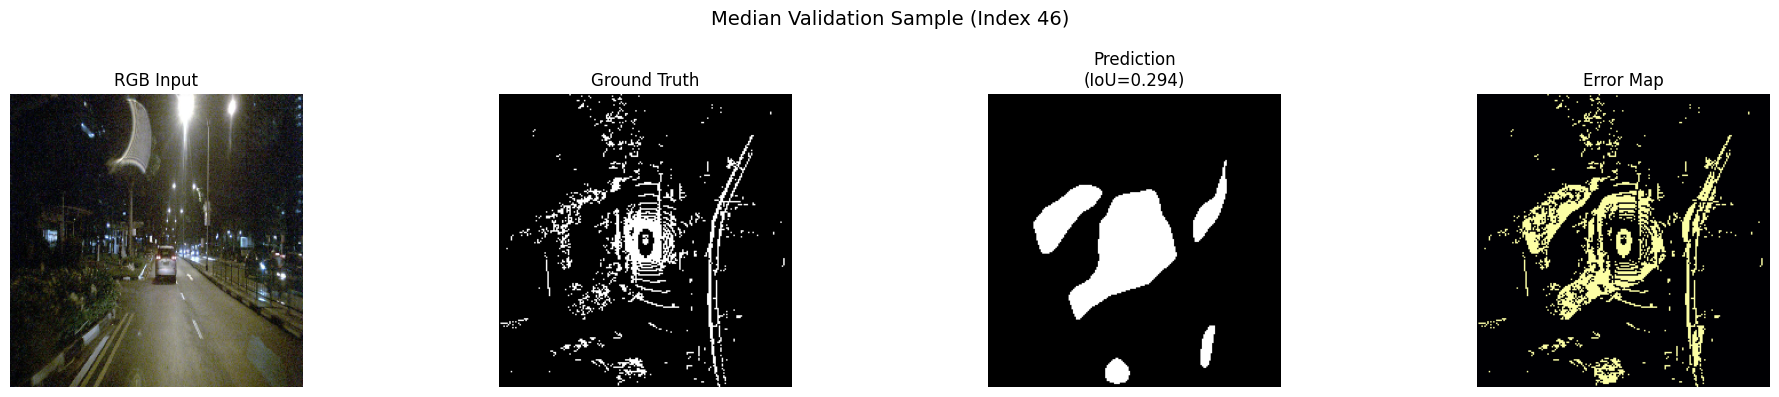

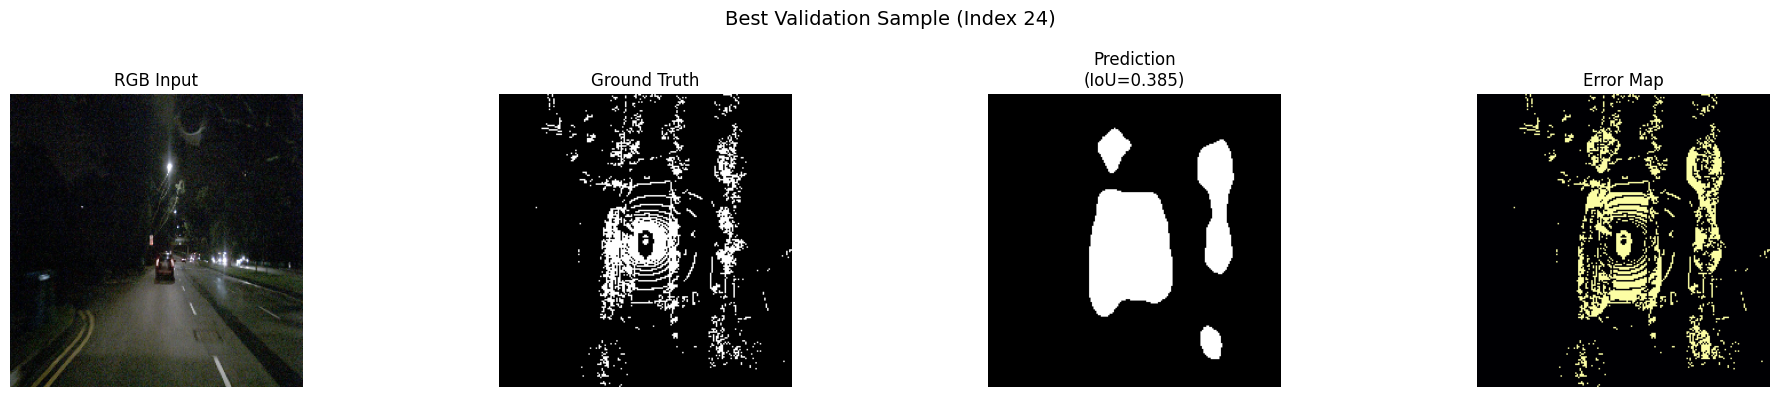

In [ ]:
# ============================================================
# Error Analysis
#
# Analyze representative validation examples corresponding to
# the worst, median, and best IoU scores.
#
# This provides insight into model strengths and failure cases
# beyond aggregate performance metrics.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


# ---------------------------------------------------
# Compute IoU
# ---------------------------------------------------
def compute_iou(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute binary Intersection-over-Union (IoU).
    """

    pred_bin = (pred > thresh).astype(np.uint8)

    target_bin = (target > 0.5).astype(np.uint8)

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    return intersection / (union + 1e-6)


# ---------------------------------------------------
# Evaluate every validation sample
# ---------------------------------------------------
sample_results = []

model.eval()

with torch.no_grad():

    for idx in range(len(val_set)):

        rgb, bev, imu = val_set[idx]

        rgb_in = rgb.unsqueeze(0).to(device)
        bev_in = bev.unsqueeze(0).to(device)
        imu_in = imu.unsqueeze(0).to(device)

        logits = model(
            rgb_in,
            bev_in,
            imu_in,
        )

        probs = torch.sigmoid(
            logits,
        )

        if probs.shape[-2:] != bev_in.shape[-2:]:

            probs = F.interpolate(
                probs,
                size=bev_in.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        pred_np = probs.squeeze().cpu().numpy()

        gt_np = bev.squeeze().cpu().numpy()

        iou = compute_iou(
            pred_np,
            gt_np,
        )

        sample_results.append(
            {
                "index": idx,
                "iou": iou,
                "rgb": rgb,
                "gt": gt_np,
                "pred": pred_np,
            }
        )


# ---------------------------------------------------
# Sort by IoU
# ---------------------------------------------------
sample_results.sort(
    key=lambda x: x["iou"],
)

selected_samples = [
    (
        "Worst",
        sample_results[0],
    ),
    (
        "Median",
        sample_results[
            len(sample_results) // 2
        ],
    ),
    (
        "Best",
        sample_results[-1],
    ),
]


# ---------------------------------------------------
# Visualization
# ---------------------------------------------------
for title, sample in selected_samples:

    rgb_np = np.transpose(
        sample["rgb"].cpu().numpy(),
        (1, 2, 0),
    )

    rgb_np = (
        (rgb_np + 1.0) / 2.0
    ).clip(0, 1)

    pred_bin = (
        sample["pred"] > 0.5
    ).astype(np.float32)

    error_map = np.abs(
        pred_bin - sample["gt"]
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 4),
    )

    axes[0].imshow(rgb_np)
    axes[0].set_title("RGB Input")
    axes[0].axis("off")

    axes[1].imshow(
        sample["gt"],
        cmap="gray",
    )
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(
        pred_bin,
        cmap="gray",
    )
    axes[2].set_title(
        f"Prediction\n(IoU={sample['iou']:.3f})"
    )
    axes[2].axis("off")

    axes[3].imshow(
        error_map,
        cmap="inferno",
    )
    axes[3].set_title("Error Map")
    axes[3].axis("off")

    plt.suptitle(
        f"{title} Validation Sample "
        f"(Index {sample['index']})",
        fontsize=14,
    )

    plt.tight_layout()

    plt.show()

## 7. Summary

### Objective

Evaluate whether symmetric cross-modal attention
between RGB and LiDAR features improves multimodal
RGB–LiDAR–IMU fusion for BEV occupancy prediction.

---

### Key Findings

- Training remained stable throughout optimization.
- The Cross Attention module successfully learned
  cross-modal feature interactions.
- Best Validation IoU reached **0.291**.
- Mean Validation IoU reached **0.300**.
- Performance remained below both the Fusion Baseline
  and Fusion + CBAM architectures.

---

### Interpretation

Although cross-modal attention enabled feature
interaction between RGB and LiDAR representations,
the resulting predictions became overly smooth and
failed to preserve fine-grained occupancy structures.

Qualitative evaluation and error analysis indicate
that the model successfully localized the dominant
occupied region but struggled to reconstruct detailed
spatial geometry, leading to reduced IoU and F1 score.

---

### Conclusion

This experiment demonstrates that introducing
cross-modal attention alone does not necessarily
improve multimodal BEV perception.

For this dataset, simpler convolutional fusion
strategies preserved local spatial information more
effectively than the proposed Cross Attention design.

The experiment provides a valuable negative ablation,
highlighting the importance of validating architectural
choices through controlled experimentation.

---

### Future Work

- Hybrid X-Attention fusion
- Multi-scale cross-modal attention
- Local window attention
- Hierarchical transformer fusion
- Adaptive modality weighting